In [1]:
import kagglehub
import os
import cv2
import random
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

c:\project\DigitalForensics\signature-forgery-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_images(folder_path, folder_type, target_size=(128, 128), sample_count=5):
    images = []
    labels = []
    all_filenames = []
    sample_images = []
    sample_labels = []  

    if not os.path.isdir(folder_path):
        print(f"Warning: Folder {folder_path} does not exist.")
        return np.array(images), np.array(labels), all_filenames

    print(f"Loading images from subfolders of: {folder_path}")

    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    img = load_img(img_path, target_size=target_size)
                    img = img_to_array(img)
                    img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
                    img_array = img / 255.0
                    img_array = np.expand_dims(img_array, axis=-1)

                    if len(sample_images) < sample_count:
                        sample_images.append(img_array)
                        sample_labels.append('Real' if folder_type.lower() == 'real' else 'Forged')

                    images.append(img_array)
                    labels.append(1 if folder_type.lower() == 'real' else 0)
                    all_filenames.append(img_path)
                except Exception as e:
                    print(f"Error processing file {img_path}: {e}")

    if sample_images:
        fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))
        for ax, sample_img, sample_label in zip(axes, sample_images, sample_labels):
            ax.imshow(sample_img.squeeze(), cmap='gray')
            ax.set_title(sample_label, fontsize=10)  # Use label instead of filename
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    print(f"Total images loaded: {len(images)}")
    return np.array(images), np.array(labels), all_filenames

In [3]:
path = kagglehub.dataset_download("tienen/handwritten-signature-verification")

In [4]:
# ...existing code...

f_data = "C:/project/DigitalForensics/signature-forgery-detection/data/forged"
r_data = "C:/project/DigitalForensics/signature-forgery-detection/data/real"

# ...existing code...

Loading images from subfolders of: C:/project/DigitalForensics/signature-forgery-detection/data/forged
Error processing file C:/project/DigitalForensics/signature-forgery-detection/data/forged\ru.d1c664d6-431d-4985-9e21-5989b1b7df4b__0001e12109--61ff34f8f73c4b173c32986d__JP A.jpg: cannot identify image file <_io.BytesIO object at 0x000001D77B10DA80>


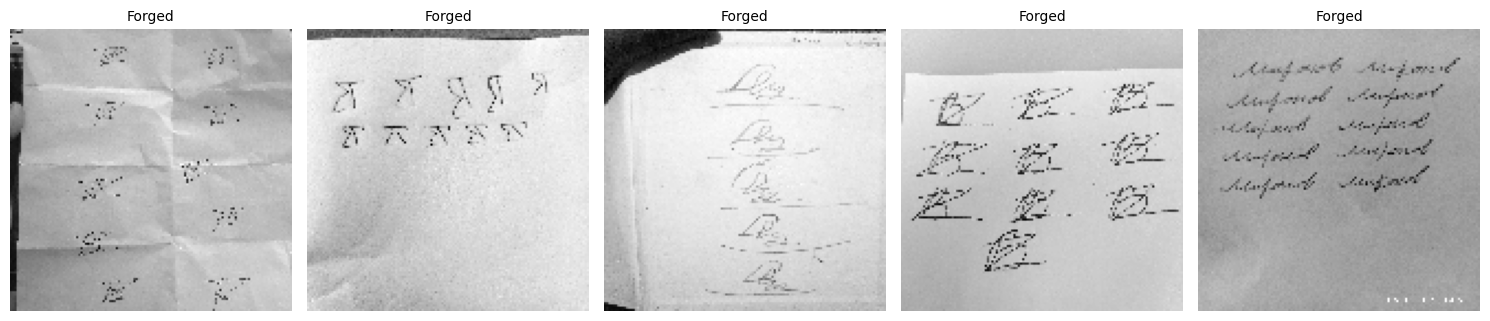

Total images loaded: 2983
Loading images from subfolders of: C:/project/DigitalForensics/signature-forgery-detection/data/real


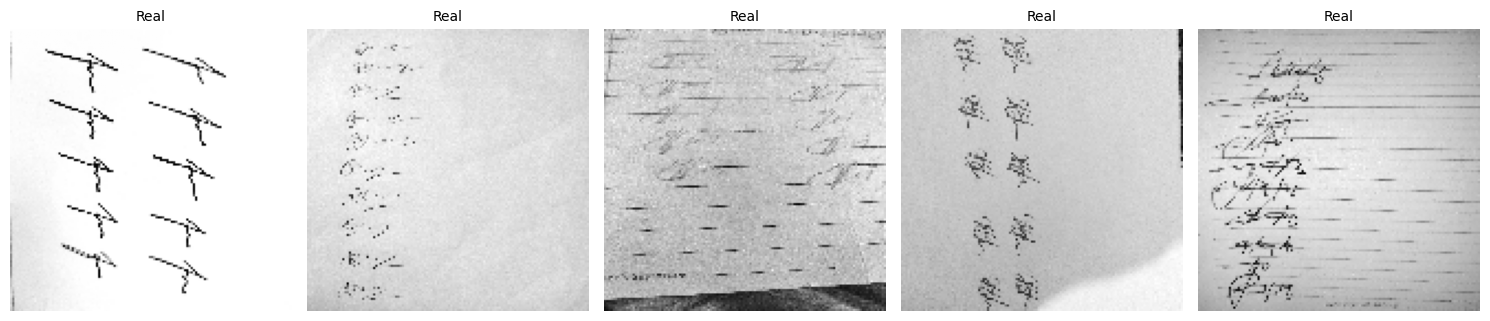

Total images loaded: 3188


In [5]:
imgs_f, labels_f, k = load_images(f_data, "forged")
imgs_r, labels_r, l = load_images(r_data, "real")

#Pre-Processing

In [6]:
all_images = np.concatenate((imgs_f, imgs_r), axis=0)
all_labels = np.concatenate((labels_f, labels_r), axis=0)


all_images, all_labels = shuffle(all_images, all_labels, random_state=42)

In [7]:
all_labels = to_categorical(all_labels,num_classes = 2)

In [8]:
all_labels.shape

(6171, 2)

In [9]:
all_images.shape

(6171, 128, 128, 1)

In [10]:
x_train, x_test, y_train, y_test = train_test_split(all_images, all_labels, test_size=0.3, random_state=42)

In [11]:
print(x_train.shape)
x_test.shape

(4319, 128, 128, 1)


(1852, 128, 128, 1)

In [12]:
train_datagen = ImageDataGenerator(       
    rotation_range=35,               
    width_shift_range=0.3,           
    height_shift_range=0.2,          
    shear_range=0.3,                 
    horizontal_flip=True,                    
)


train_generator = train_datagen.flow(x_train, y_train, batch_size=128) 

Model
Helper Function

In [13]:
def plot_train(hist):
    history = hist.history

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].plot(history['loss'], label='Training Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss Over Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid()

    if 'accuracy' in history:  # Adjust for older versions with 'acc'
        axes[1].plot(history['accuracy'], label='Training Accuracy')
        axes[1].plot(history['val_accuracy'], label='Validation Accuracy')
        axes[1].set_title('Model Accuracy Over Epochs')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid()


    plt.tight_layout()
    plt.show()

In [14]:
base_model = ResNet50(include_top=False, weights=None, input_shape=(128, 128, 1))

for layer in base_model.layers[:30]:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)  
x = Dense(128, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
predictions = Dense(2, activation='softmax')(x)  

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)


In [15]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=25,
    callbacks=[early_stopping],
    batch_size = 128
)

c:\project\DigitalForensics\signature-forgery-detection\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 378s 10s/step - accuracy: 0.5141 - loss: 4.8274 - val_accuracy: 0.4951 - val_loss: 4.5043
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 306s 9s/step - accuracy: 0.5223 - loss: 4.4349 - val_accuracy: 0.4951 - val_loss: 4.2015
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 318s 9s/step - accuracy: 0.5394 - loss: 4.1228 - val_accuracy: 0.4951 - val_loss: 3.9186
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 323s 10s/step - accuracy: 0.5512 - loss: 3.8298 - val_accuracy: 0.4951 - val_loss: 3.6980
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 316s 9s/step - accuracy: 0.5587 - loss: 3.5554 - val_accuracy: 0.4951 - val_loss: 3.4243
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 279s 8s/step - accuracy: 0.5505 - loss: 3.3155 - val_accuracy: 0.4951 - val_loss: 3.2056
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 368s 10s/step - accuracy: 0.5838 - loss: 3.0772 - val_accuracy: 0.4951 - val_loss: 3.0429
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5806 - loss: 2.8680

KeyboardInterrupt: 

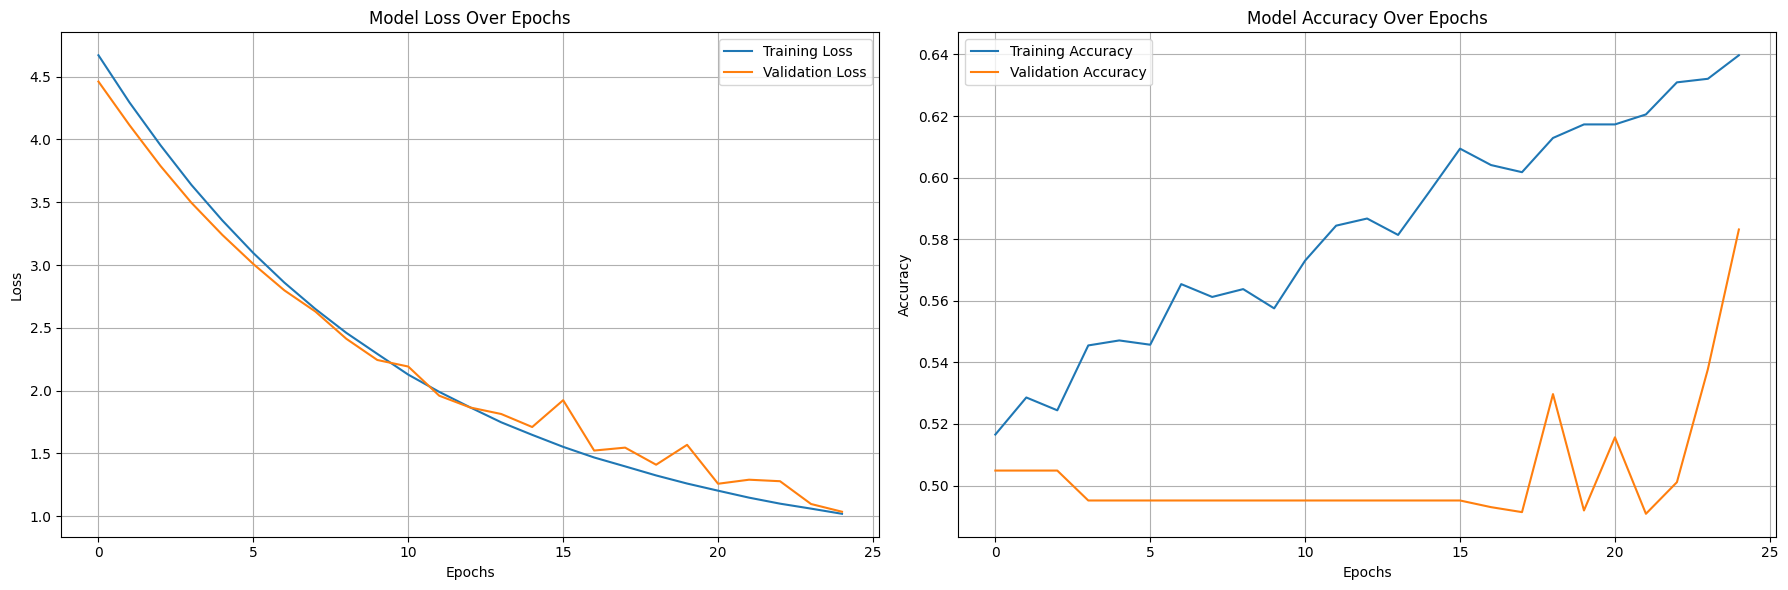

In [ ]:
plot_train(history)

In [ ]:
for layer in base_model.layers[-30:]:  
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_tuned = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=100,
    callbacks=[early_stopping],
    batch_size = 128
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 175s 5s/step - accuracy: 0.6565 - loss: 0.9964 - val_accuracy: 0.6096 - val_loss: 1.0136
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 160s 5s/step - accuracy: 0.6717 - loss: 0.9674 - val_accuracy: 0.6339 - val_loss: 0.9957
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.6540 - loss: 0.9639 - val_accuracy: 0.6436 - val_loss: 0.9808
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - accuracy: 0.6484 - loss: 0.9643 - val_accuracy: 0.6415 - val_loss: 0.9765
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 161s 5s/step - accuracy: 0.6533 - loss: 0.9522 - val_accuracy: 0.6409 - val_loss: 0.9687
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 170s 5s/step - accuracy: 0.6735 - loss: 0.9395 - val_accuracy: 0.6490 - val_loss: 0.9573
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 166s 5s/step - accuracy: 0.6605 - loss: 0.9397 - val_accuracy: 0.6506 - val_loss: 0.9572
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 170s 5s/step - accuracy: 0.6525 - loss: 0.9336 - val_accuracy: 0.